In [76]:
import os
import time
from langchain_groq import ChatGroq
from pydantic import BaseModel, Field
from typing import Annotated, TypedDict,Literal,List
from dotenv import load_dotenv
from langchain_core.messages import BaseMessage,HumanMessage
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver

In [77]:
load_dotenv()

True

In [78]:
llm=ChatGroq(
    model="llama-3.1-8b-instant",
    api_key=os.getenv("GROQ_API_KEY"),
)

In [79]:
class JokeState(TypedDict):
    topic:str
    joke:str
    Explanation:str
    

In [80]:
graph=StateGraph(JokeState)

In [81]:
def gen_joke(state:JokeState)->JokeState:
    topic=state["topic"]
    prompt=f"genrate a joke about the topic {topic} ."
    messages=[HumanMessage(content=prompt)]
    response=llm.invoke(messages)
    return {'joke':response.content}
def explain_joke(state:JokeState)->JokeState:
    joke=state["joke"]
    prompt=f"explain the joke {joke} in simple words."
    print("waiting for 30 seconds before calling the LLM to avoid rate limit")
    time.sleep(5)
    messages=[HumanMessage(content=prompt)]
    response=llm.invoke(messages)
    return {'Explanation':response.content}

In [82]:
graph.add_node("Gen Joke",gen_joke)
graph.add_node("Explain Joke",explain_joke)
graph.add_edge(START,"Gen Joke")
graph.add_edge("Gen Joke","Explain Joke")
graph.add_edge("Explain Joke",END)

In [83]:
checkpointer =InMemorySaver()
workflow=graph.compile(checkpointer=checkpointer)

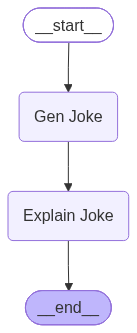

In [84]:
workflow

In [92]:
thread_id="2"
# thread_id-"2"
config={'configurable':{"thread_id":thread_id}}
final_state=workflow.invoke({"topic":"pen"},config=config)

waiting for 30 seconds before calling the LLM to avoid rate limit


In [93]:
final_state

{'topic': 'pen',
 'joke': 'Why did the pen go to therapy?\n\nBecause it was feeling a little "drawn out" and had a lot of "pen-ding" issues.',
 'Explanation': 'The joke is a play on words. It\'s using a pen as a main character and making puns related to its purpose.\n\n- "Drawn out" can mean two things: feeling sad or taking too long to finish something. Since a pen is used for drawing, it\'s a clever connection.\n- "Pen-ding" is a pun on the word "pending", which means something that\'s being considered or dealt with. Here, it implies that the pen has issues that need to be dealt with.\n\nSo, the joke is saying that the pen went to therapy because it was feeling down (drawn out) and had problems (pen-ding issues) that needed to be resolved.'}

In [100]:
workflow.get_state(config={'configurable':{"thread_id":"1"}})

StateSnapshot(values={'topic': 'programming', 'joke': 'Why do programmers prefer dark mode?\n\nBecause light attracts bugs.', 'Explanation': 'This joke is a play on words. It\'s a pun.\n\nIn simple words: \n\n- "Bugs" in programming usually means errors or problems in the code.\n- In contrast, "bugs" in nature are typically small insects like mosquitoes or flies.\n\nSo, the joke says that programmers prefer dark mode (a mode that makes the screen darker) because light attracts (or brings) bugs (the errors) rather than the insects. It\'s a clever and humorous way to connect two different meanings of the word "bugs".'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f18dd9a-cd33-60f4-8002-b46c97016952'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-08-01T18:49:07.213687+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f18dd9a-98a3-6ba4-8001-4ec09065241d'}}, tasks=(), 

In [99]:
list(workflow.get_state_history(config={'configurable':{"thread_id":"2"}}))

[StateSnapshot(values={'topic': 'pen', 'joke': 'Why did the pen go to therapy?\n\nBecause it was feeling a little "drawn out" and had a lot of "pen-ding" issues.', 'Explanation': 'The joke is a play on words. It\'s using a pen as a main character and making puns related to its purpose.\n\n- "Drawn out" can mean two things: feeling sad or taking too long to finish something. Since a pen is used for drawing, it\'s a clever connection.\n- "Pen-ding" is a pun on the word "pending", which means something that\'s being considered or dealt with. Here, it implies that the pen has issues that need to be dealt with.\n\nSo, the joke is saying that the pen went to therapy because it was feeling down (drawn out) and had problems (pen-ding issues) that needed to be resolved.'}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f18dd9c-080a-6398-8002-eba2fb87b1e8'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-08-01T18:49:40.227151

In [89]:
final_state=workflow.invoke(None,config=config) #this code is for checking fault tolerance, it will resume from the last state and continue the workflow

In [90]:
final_state

{'topic': 'programming',
 'joke': 'Why do programmers prefer dark mode?\n\nBecause light attracts bugs.',
 'Explanation': 'This joke is a play on words. It\'s a pun.\n\nIn simple words: \n\n- "Bugs" in programming usually means errors or problems in the code.\n- In contrast, "bugs" in nature are typically small insects like mosquitoes or flies.\n\nSo, the joke says that programmers prefer dark mode (a mode that makes the screen darker) because light attracts (or brings) bugs (the errors) rather than the insects. It\'s a clever and humorous way to connect two different meanings of the word "bugs".'}

In [91]:
workflow.get_state(config=config)

StateSnapshot(values={'topic': 'programming', 'joke': 'Why do programmers prefer dark mode?\n\nBecause light attracts bugs.', 'Explanation': 'This joke is a play on words. It\'s a pun.\n\nIn simple words: \n\n- "Bugs" in programming usually means errors or problems in the code.\n- In contrast, "bugs" in nature are typically small insects like mosquitoes or flies.\n\nSo, the joke says that programmers prefer dark mode (a mode that makes the screen darker) because light attracts (or brings) bugs (the errors) rather than the insects. It\'s a clever and humorous way to connect two different meanings of the word "bugs".'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f18dd9a-cd33-60f4-8002-b46c97016952'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-08-01T18:49:07.213687+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f18dd9a-98a3-6ba4-8001-4ec09065241d'}}, tasks=(), 